# 05 — School block: value vs cost (standalone check)
The final model uses teacher features only. This notebook is the receipt for dropping the 19
school-context features: on teachers with complete school data, the block barely moves AUC —
while requiring it shrinks the sample and hits some countries much harder than others.
Backs the "school block context omitted by necessity" limitation slide.

Standalone: rebuilds the sample itself (setup cells copied verbatim from `02_modeling.ipynb`
CELLS 1-6 — if those change there, re-copy them here). Reads the same merged CSV as 02.

In [1]:
# ============================================================
# CELL 0 — paths (portable: finds the repo by walking up from cwd)
# No editing needed on any machine. If it errors, open the repo
# folder itself in VS Code / Jupyter and restart the kernel.
# ============================================================
from pathlib import Path

def find_root(start=None, depth=6):
    p = start or Path.cwd()
    for _ in range(depth):
        if (p / "Data").exists() and (p / "Model").exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        f"repo root not found walking up from {Path.cwd()} — "
        "in VS Code use File > Open Folder on summer26-teacher-ai-readiness, "
        "reopen this notebook, restart the kernel")

ROOT = find_root()
DATA_DIR = ROOT / "Data"                 # codebook + small CSVs
SPSS_DIR = DATA_DIR / "SPSS"             # raw TALIS .sav files (gitignored)
OUT_DIR  = DATA_DIR / "output"           # everything the notebooks produce (gitignored)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", ROOT)

repo root: c:\Users\elif_\Documents\summer26-teacher-ai-readiness


In [2]:
import matplotlib.pyplot as plt

In [3]:
# ============================================================
# CELL 1 — load merged file, build ai_sample
# ============================================================
import re
import numpy as np
import pandas as pd

merged = pd.read_csv(DATA_DIR / "output" / "teacher_principal_named_columns.csv",
                     encoding="utf-8-sig", low_memory=False)
assert any(c.startswith("P_TC") for c in merged.columns), "no principal columns - wrong file?"

q36_col = next(c for c in merged.columns if c.startswith("TT4G36"))
q36_num = pd.to_numeric(merged[q36_col], errors="coerce")
ai_sample = merged[q36_num != 8].copy()
ai_sample[q36_col] = pd.to_numeric(ai_sample[q36_col], errors="coerce").replace(9, np.nan)
print("administered the AI module:", len(ai_sample))

administered the AI module: 92894


In [5]:
# ============================================================
# CELL 2 — teacher features (RQ1) + prep_general + belief composites
# Definitions = official TALIS 2024 codebook labels (abbreviated)
# ============================================================
cb = pd.read_csv(DATA_DIR / "talis2024_teacher_codebook.csv")

def tcol(v):
    """short code -> actual teacher column name in merged/ai_sample"""
    return next(c for c in ai_sample.columns if c.startswith(v + " ") or c == v)

# --- AI-belief COMPOSITES (mean of items; code 5 "I don't know" -> missing) ---
# Q35 scale: 1=Strongly disagree ... 4=Strongly agree, 5=I don't know (NOT on scale)
def belief_mean(items):
    B = ai_sample[[tcol(v) for v in items]].apply(pd.to_numeric, errors='coerce')
    B = B.replace(5, 2.5)                       # ← THIS LINE: "don't know" (5) -> neutral 2.5
    B = B.where(B.isin([1, 2, 2.5, 3, 4]))      # ← note 2.5 added to valid values
    return B.mean(axis=1).where(B.notna().sum(axis=1) >= 1)
ai_sample['ai_benefit_mean'] = belief_mean([f'TT4G35{c}' for c in 'ABCDE'])  # benefits
ai_sample['ai_risk_mean']    = belief_mean([f'TT4G35{c}' for c in 'FGHIJ'])  # risks/concerns

# --- general pedagogical preparation composite ---
# Q7a-e,g: prepared for content / subject pedagogy / general pedagogy /
# classroom practice / multicultural settings / student development
prep_codes = ['TT4G07A', 'TT4G07B', 'TT4G07C', 'TT4G07D', 'TT4G07E', 'TT4G07G']
P = ai_sample[[tcol(v) for v in prep_codes]].apply(pd.to_numeric, errors='coerce')
P = P.where(~P.isin([6, 8, 9]))
ai_sample['prep_general'] = P.mean(axis=1).where(P.notna().sum(axis=1) >= 4)

feature_cols = (
    # --- AI / digital core ---
    ['TT4G21G',   # Q21g: professional learning included "using AI for teaching and learning" (yes/no)
     'TT4G07F',   # Q7f: felt prepared for "use of digital resources and tools" (initial education)
     'TT4G27M']   # Q27m: self-efficacy — support learning through digital resources and tools

    # --- AI beliefs: two COMPOSITE scores (replaces the 10 Q35 items) ---
    + ['ai_benefit_mean',  # mean of Q35A-E; higher = agrees AI is beneficial
       'ai_risk_mean']     # mean of Q35F-J; higher = agrees AI is risky/concerning

    # --- derived: general pedagogical preparation ---
    + ['prep_general']

    # --- professional environment (TALIS derived scales) ---
    + ['T4COLES',   # Professional collaboration in lessons among teachers
       'T4TLEAD',   # Teacher leadership
       'T4VALP']    # Perceptions of value and policy influence
                    # NOTE: T4SELF (overall self-efficacy) dropped — overlaps with
                    # TT4G27M (digital self-efficacy), the AI-relevant facet we keep

    # --- wellbeing / stress (derived scales) ---
    + ['T4JOBSAT',  # Job satisfaction, overall
       'T4WLOADT',  # Workload stress
       'T4STBEH',   # Student behaviour stress
       'T4CHFAT']   # Change fatigue

    # --- workload ---
    + ['TT4G15']    # Q15: hours teaching at this school, most recent full week

    # --- demographics / employment (grouped) ---
    + ['T4TAGEGR',  # Teacher age (grouped)
       'T4TEMPWH',  # Employment status by working hours (grouped; CATEGORICAL)
       'T4TNSCH']   # Number of schools the teacher works at

    # --- structure ---
    + ['CNTRY']     # Country alpha code (CATEGORICAL, fixed effect)
)

withlabels = {
    'TT4G21G':         'Received AI Training',
    'ai_benefit_mean': 'AI-benefit beliefs',
    'ai_risk_mean':    'AI-risk beliefs',
    'CNTRY':           'Country',
    'TT4G27M':         'Digital self-efficacy',
    'TT4G07F':         'Digital preparedness',
    'prep_general':    'General preparation',
    'T4TAGEGR':        'Age group',
    'T4COLES':         'Professional collaboration',
    'T4TLEAD':         'Teacher leadership',
    'T4VALP':          'Perceived value & influence',
    'T4JOBSAT':        'Job satisfaction',
    'T4WLOADT':        'Workload stress',
    'T4STBEH':         'Student-behaviour stress',
    'T4CHFAT':         'Change fatigue',
    'TT4G15':          'Teaching hours',
    'T4TEMPWH':        'Employment status',
    'T4TNSCH':         'Number of schools',
}

assert len(feature_cols) == len(set(feature_cols))
print("teacher features:", len(feature_cols))   # 18

teacher features: 18


### Checking which principal (school-level) variables are usable

The principal survey is merged in with a `P_` prefix, so each teacher carries their school's principal answers. Before using any of them as features, we check two things per variable:

- **Availability** — what % of teachers have a valid answer (excluding survey missing codes). We only keep variables answered by **≥90%** of matched teachers, so they don't shrink the sample.
- **Usefulness** — a variable that's constant (one value everywhere) carries no signal, so it's flagged and dropped.

We also report the **match rate**: the share of AI-module teachers whose school actually has a principal record. Teachers without a matched principal get `NaN` on all school variables and would drop out at the complete-case step, so this number bounds how much the school block can cost us.

The `school_shortlist` is our theory-motivated candidate set (digital infrastructure, principal leadership, decision authority, school structure); the printout confirms each one clears the availability bar before we commit to it.

In [6]:
# Principal-variable availability (in-memory, uses merged's column names) ----
import re

pcols   = [c for c in ai_sample.columns if c.startswith('P_')]
base_of  = {c: c[2:].split(' ')[0] for c in pcols}
label_of = {c: c[2:].split(' ', 1)[1] if ' ' in c[2:] else '' for c in pcols}

admin_pat = re.compile(r'^(ID|CNTRY|VERSION|IEADATE|ADJRT|IDPOP|.*WGT)')
keep = [c for c in pcols if not admin_pat.match(base_of[c])]

missing_codes = [6, 7, 8, 9, 96, 97, 98, 99, 998, 999, 9998, 9999]
matched = ai_sample[keep].notna().any(axis=1)
print(f"principal match rate in AI sample: {matched.mean()*100:.1f}%")

rows = []
for c in keep:
    s = pd.to_numeric(ai_sample[c], errors='coerce')
    valid = (~s.isin(missing_codes) & s.notna())[matched].mean() * 100
    nun = s[~s.isin(missing_codes)].nunique()
    rows.append({'variable': base_of[c], 'pct_valid_matched': round(valid, 1),
                 'n_unique': nun,
                 'flag': 'CONSTANT' if nun <= 1 else 'BINARY' if nun == 2 else
                         'HIGH-CARD' if nun > 20 else '',
                 'label': label_of[c][:80]})

pav = pd.DataFrame(rows).sort_values('pct_valid_matched')
usable_n = ((pav.pct_valid_matched >= 90) & (pav.flag != 'CONSTANT')).sum()
print(f"usable principal predictors (>=90%, non-constant): {usable_n} of {len(pav)}")

# our candidate school block — check these specifically
school_shortlist = ['TC4G40E','TC4G28A','TC4G08H','T4SCHLOC','T4NUMSTUD',
                    'T4STRATIO','T4PLACMR','T4PLEADS','T4PAUTI']
print("\n--- shortlist status ---")
print(pav[pav.variable.isin(school_shortlist)].to_string(index=False))

pav.to_csv(OUT_DIR / "principal_availability.csv", index=False)

principal match rate in AI sample: 96.7%
usable principal predictors (>=90%, non-constant): 329 of 370

--- shortlist status ---
 variable  pct_valid_matched  n_unique      flag                                                                            label
  T4PAUTI               93.3         3                                                 School autonomy for instructional policies
 T4PLACMR               94.9         3                                                                 Lack of material resources
T4STRATIO               96.1      2894 HIGH-CARD                                                            Student-teacher ratio
T4NUMSTUD               96.6         3                                                      Number of enrolled students (grouped)
  TC4G40E               96.9         4           School Climate/ Capacity to provide instruction/ Shortage or inadequacy of <digi
  TC4G08H               97.4         4           Personal Background/ Participation in prof

In [7]:
# ============================================================
# CELL 3 — school context block (16 principal vars + 3 disagreement gaps)
# Gaps are built here to TEST them; confirmed null in importance and
# dropped for the final model — the value-vs-cost test lives in
# 03_school_block_check.ipynb (standalone).
# Definitions from the principal codebook.
# ============================================================
school_vars = [
    'TC4G40E',    # Q40e: instruction hindered by shortage/inadequacy of digital technology
    'TC4G28A',    # Q28a: principal took actions to support integration of digital resources
    'TC4G08H',    # Q8h: principal's own PL included developing a digital-resources strategy
    'TC4G10K',    # Q10k: principal's current NEED for PL in digital-resources strategy (1-4)
    'TC4G25A3',   # Q25a: teachers (not management) hold responsibility for deciding on
                  #        digital-resource use for teaching (checkbox)
    'T4SCHLOC',   # School location: rural/town/city (grouped; CATEGORICAL)
    'T4NUMSTUD',  # School size: number of students (grouped)
    'T4STRATIO',  # Student-teacher ratio (continuous)
    'T4PLACMR',   # Lack of material resources (derived scale)
    'T4PLACP',    # Lack of pedagogical personnel (derived scale)
    'T4PLEADS',   # Instructional leadership (principal, derived scale)
    'T4PAUTI',    # School autonomy over instructional policies
    'T4PDELI',    # School delinquency and violence (climate scale)
    'T4PACADT',   # Academic rigor (climate scale)
    'T4TTNRATIO', # New teachers / total teachers ratio (staff churn, continuous)
    'T4TTLRATIO', # Departing teachers / total teachers ratio (continuous)
]

def pcol(v):
    """short code -> actual P_ column name"""
    return next(c for c in ai_sample.columns if c.startswith(f"P_{v} ") or c == f"P_{v}")

S = ai_sample[[pcol(v) for v in school_vars]].apply(pd.to_numeric, errors='coerce')
S.columns = school_vars

# mask special codes EXCEPT on continuous ratios (real ratio values can be 6, 8, 9...)
ratio_vars = ['T4STRATIO', 'T4TTNRATIO', 'T4TTLRATIO']
mask_vars = [v for v in school_vars if v not in ratio_vars]
S[mask_vars] = S[mask_vars].where(
    ~S[mask_vars].isin([6, 8, 9, 96, 97, 98, 99, 998, 999, 9998, 9999]))

S['TC4G25A3'] = S['TC4G25A3'].map({1: 1, 2: 0})   # checkbox -> 1/0

# --- teacher-principal disagreement gaps (teacher minus principal, both z-scored) ---
#   gap_participation: T4OPPART (teacher) vs P_T4POPPART (principal) — participation in decisions
#   gap_tleadership:   T4TLEAD  (teacher) vs P_T4PTLEAD  (principal) — teacher leadership
#   gap_jobsat:        T4JOBSAT (teacher) vs P_T4PJOBSAT (principal) — job satisfaction
def z(s):
    return (s - s.mean()) / s.std()

pairs = {'gap_participation': ('T4OPPART', 'T4POPPART'),
         'gap_tleadership':   ('T4TLEAD',  'T4PTLEAD'),
         'gap_jobsat':        ('T4JOBSAT', 'T4PJOBSAT')}

for name, (tvar, pvar) in pairs.items():
    t = pd.to_numeric(ai_sample[tcol(tvar)], errors='coerce').where(lambda x: ~x.isin([9998, 9999]))
    p = pd.to_numeric(ai_sample[pcol(pvar)], errors='coerce')
    S[name] = z(t) - z(p)

school_block = list(S.columns)          # 16 principal + 3 gaps = 19
ai_sample[school_block] = S
print("school block:", len(school_block), "features (16 principal + 3 gaps)")
print(S.notna().mean().mul(100).round(1).sort_values().head(8))

school block: 19 features (16 principal + 3 gaps)
T4PAUTI              90.3
T4PLACMR             91.7
T4PLACP              92.4
T4NUMSTUD            93.4
gap_jobsat           93.4
TC4G40E              93.7
gap_participation    94.0
T4PDELI              94.0
dtype: float64


In [8]:
# ============================================================
# CELL 4 — assembly: ONE fixed complete-case sample + accounting
# ============================================================
def col_for(v):
    if v in ai_sample.columns:          # prep_general, composites
        return v
    return tcol(v)

all_short = feature_cols #+ school_block           # teacher features only (school block is for subset analysis)
D = ai_sample[[col_for(v) for v in all_short]].copy()
D.columns = all_short

# per-variable missing codes from the codebook (raw teacher vars only)
cb_codes = {}
for _, row in cb[cb.variable_name.isin(feature_cols)].iterrows():
    cb_codes[row.variable_name] = [float(x) for x in
        re.findall(r"(\d+)\s*=", str(row.special_missing_or_skip_codes))]

categoricals = ['CNTRY', 'T4SCHLOC', 'T4TEMPWH']
DERIVED = ['prep_general', 'ai_benefit_mean', 'ai_risk_mean']   # ← already clean, skip
for v in feature_cols:
    if v in categoricals or v in DERIVED:                        # ← was: == 'prep_general'
        continue
    D[v] = pd.to_numeric(D[v], errors='coerce')
    if cb_codes.get(v):
        D[v] = D[v].where(~D[v].isin(cb_codes[v]))

D['TT4G21G'] = D['TT4G21G'].map({1: 1, 2: 0})     # yes/no -> 1/0

D['y'] = (pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1).astype(float)
D.loc[ai_sample[q36_col].isna(), 'y'] = np.nan
D['IDSCHOOL'] = ai_sample[next(c for c in ai_sample.columns if c.startswith('IDSCHOOL'))]
D['CNTRY'] = D['CNTRY'].astype(str).str.strip()
D['T4TEMPWH'] = pd.to_numeric(D['T4TEMPWH'], errors='coerce').where(
    lambda s: ~s.isin([8, 9]))

# ---- missingness accounting ----
n0 = len(D)
print("worst 10 columns by missingness (%):")
print(D[all_short].isna().mean().mul(100).round(1).sort_values(ascending=False).head(10).to_string())

data = D.dropna()
print(f"\ncomplete cases: {len(data):,} of {n0:,}  ({len(data)/n0*100:.1f}%)")
print(f"AI-use rate: full {D['y'].mean():.3f}  |  complete-case {data['y'].mean():.3f}")

kept = pd.Series(D.index.isin(data.index), index=D.index)
drop_by_cntry = (1 - kept.groupby(D['CNTRY']).mean()).mul(100).round(1)
print("\ncountries losing the most rows (%):")
print(drop_by_cntry.sort_values(ascending=False).head(8).to_string())

for v in ['T4TAGEGR', 'TT4G21G']:
    print(f"{v}: kept mean {D.loc[kept, v].mean():.3f} | dropped mean {D.loc[~kept, v].mean():.3f}")

cc = data['CNTRY'].value_counts()
print("\nsmallest country cells:", cc.tail(3).to_dict())
print("countries with <200 rows:", (cc < 200).sum())

worst 10 columns by missingness (%):
TT4G21G         7.0
T4VALP          3.7
T4JOBSAT        3.6
T4CHFAT         3.5
T4STBEH         3.5
T4WLOADT        3.4
TT4G07F         3.1
T4TLEAD         2.9
prep_general    2.8
TT4G15          2.6

complete cases: 75,817 of 92,894  (81.6%)
AI-use rate: full 0.409  |  complete-case 0.414

countries losing the most rows (%):
CNTRY
NLD    100.0
SGP    100.0
HRV     56.0
SAU     31.0
SWE     30.3
ISR     28.7
XKX     28.0
ZAF     27.0
T4TAGEGR: kept mean 2.877 | dropped mean 2.942
TT4G21G: kept mean 0.414 | dropped mean 0.437

smallest country cells: {'NOR': 380, 'ISL': 343, 'MNE': 340}
countries with <200 rows: 0


In [9]:
# ============================================================
# CELL 6 — school-grouped split + helpers (used by all comparisons)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import norm

RANDOM_STATE = 42
CATEGORICALS = ['CNTRY', 'T4TEMPWH']          # T4SCHLOC gone (school block out)

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(data, data['y'], groups=data['IDSCHOOL']))
train, test = data.iloc[tr_idx], data.iloc[te_idx]
assert not (set(train['IDSCHOOL']) & set(test['IDSCHOOL'])), "schools leak!"
print(f"train {len(train):,} | test {len(test):,}")
print(f"AI share — train {train['y'].mean():.3f} | test {test['y'].mean():.3f}")

def make_pipe(feats, clf=None):
    cat = [c for c in feats if c in CATEGORICALS]
    num = [c for c in feats if c not in CATEGORICALS]
    steps = [('num', StandardScaler(), num)]
    if cat:
        steps.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat))
    if clf is None:
        clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
    return Pipeline([('prep', ColumnTransformer(steps)), ('clf', clf)])


HEADLINE_CLF = lambda: GradientBoostingClassifier(random_state=RANDOM_STATE)

def delong(y, p1, p2):
    y = np.asarray(y); pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    def struct(p):
        x, yv = p[pos], p[neg]
        v10 = np.array([(np.sum(xi > yv) + .5*np.sum(xi == yv))/n for xi in x])
        v01 = np.array([(np.sum(x > yi) + .5*np.sum(x == yi))/m for yi in yv])
        return v10, v01, v10.mean()
    a1v,a1w,a1 = struct(np.asarray(p1)); a2v,a2w,a2 = struct(np.asarray(p2))
    s10 = np.cov(np.vstack([a1v,a2v])); s01 = np.cov(np.vstack([a1w,a2w]))
    var = (s10[0,0]+s10[1,1]-2*s10[0,1])/m + (s01[0,0]+s01[1,1]-2*s01[0,1])/n
    z = (a1-a2)/np.sqrt(var) if var > 0 else 0.0
    return a1, a2, 2*norm.sf(abs(z))

train 52,533 | test 23,284
AI share — train 0.414 | test 0.412


In [10]:
# ============================================================
# APPENDIX A1 — school block: value vs cost
# Requires the setup cells above (copied from 02_modeling CELLS 1-6).
# ============================================================

# ---- attach school vars to the fixed complete-case sample (indices align) ----
new_cols = [c for c in school_block if c not in data.columns]
assert new_cols == school_block, \
    "data already has school columns — check CELL 4: school_block must stay commented out of all_short; restart kernel"
ds_full = data.join(ai_sample[school_block])
ds = ds_full.dropna()

# ---- which school variables cost the most rows? ----
print("missingness per school variable (%), worst first:")
print(ds_full[school_block].isna().mean().mul(100).round(1)
      .sort_values(ascending=False).to_string())
print()

# ---- COST: rows and countries lost by requiring complete school data ----
print(f"teacher-feature sample: {len(data):,}")
print(f"+ complete school data: {len(ds):,}  ({len(ds)/len(data)*100:.1f}% kept)")

kept = pd.Series(ds_full.index.isin(ds.index), index=ds_full.index)
loss = (1 - kept.groupby(ds_full['CNTRY']).mean()).mul(100).round(1).sort_values(ascending=False)
print("\ncountries losing the most rows (%):")
print(loss.head(10).to_string())

n_before = ds_full['CNTRY'].value_counts()
n_after  = ds['CNTRY'].value_counts().reindex(n_before.index).fillna(0).astype(int)
gone  = n_after[n_after == 0].index.tolist()
thin  = n_after[(n_after > 0) & (n_after < 200)].index.tolist()
print(f"\ncountries dropping out entirely: {gone if gone else 'none'}")
print(f"countries falling below 200 rows: {thin if thin else 'none'}")

# ---- VALUE: same subset, same grouped split — with vs without the block ----
gss_s = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
tr_s, te_s = next(gss_s.split(ds, ds['y'], groups=ds['IDSCHOOL']))
train_s, test_s = ds.iloc[tr_s], ds.iloc[te_s]

teach_feats  = feature_cols[:]                     # full teacher model (18 features)
school_feats = teach_feats + school_block

# T4SCHLOC is categorical — local pipe so the global CATEGORICALS stays untouched
def make_pipe_s(feats, clf=None):
    cats = [c for c in feats if c in CATEGORICALS + ['T4SCHLOC']]
    num  = [c for c in feats if c not in cats]
    steps = [('num', StandardScaler(), num)]
    if cats:
        steps.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cats))
    return Pipeline([('prep', ColumnTransformer(steps)),
                     ('clf', clf or HEADLINE_CLF())])

p_teach  = (make_pipe_s(teach_feats).fit(train_s[teach_feats],  train_s['y'])
            .predict_proba(test_s[teach_feats])[:, 1])
p_school = (make_pipe_s(school_feats).fit(train_s[school_feats], train_s['y'])
            .predict_proba(test_s[school_feats])[:, 1])

a_t, a_s, pval = delong(test_s['y'], p_school, p_teach)
print(f"\nsame subset, same split — teacher features:        AUC {a_s:.3f}")
print(f"same subset, same split — + 19 school features:    AUC {a_t:.3f}")
print(f"gain: {a_t - a_s:+.3f}   (DeLong p = {pval:.3f})")
print("\nverdict: the block costs sample and country coverage; the AUC gain doesn't pay for it.")

missingness per school variable (%), worst first:
T4PAUTI              9.5
T4PLACMR             7.6
T4PLACP              7.0
TC4G40E              5.7
T4PDELI              5.4
T4PACADT             5.4
TC4G08H              5.3
TC4G28A              5.1
T4PLEADS             4.9
TC4G25A3             4.5
TC4G10K              4.3
T4NUMSTUD            4.1
T4SCHLOC             4.0
gap_participation    3.0
T4STRATIO            2.9
T4TTNRATIO           2.9
T4TTLRATIO           2.9
gap_tleadership      2.9
gap_jobsat           2.9

teacher-feature sample: 75,817
+ complete school data: 63,544  (83.8% kept)

countries losing the most rows (%):
CNTRY
JPN    100.0
ISL    100.0
POL    100.0
MNE     32.1
NOR     27.9
SWE     26.7
SVN     26.4
ZAF     25.8
ISR     25.6
CAB     24.6

countries dropping out entirely: ['JPN', 'POL', 'ISL']
countries falling below 200 rows: none

same subset, same split — teacher features:        AUC 0.830
same subset, same split — + 19 school features:    AUC 0.829
gain: -

## Country cost, visualized
Which countries pay for requiring complete school data — worst 12, maroon = drops out entirely.

countries losing the most rows (%):
       lost_%  rows_before  rows_after
CNTRY                                 
JPN     100.0         1944           0
ISL     100.0          343           0
POL     100.0         1176           0
MNE      32.1          340         231
NOR      27.9          380         274
SWE      26.7          707         518
SVN      26.4         2654        1953
ZAF      25.8          803         596
ISR      25.6          777         578
CAB      24.6          513         387
AZE      22.9         1189         917
NZL      20.7          793         629


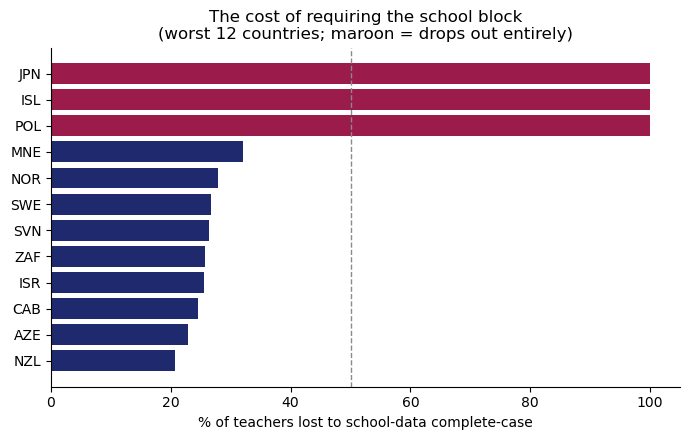

In [11]:
# ============================================================
# A2 — country-loss figure: the cost of the school block, per country
# Requires: data, ai_sample, school_block, ds_full/ds (A1 above)
# ============================================================
NAVY, MAROON, GRAY = '#1E2A6D', '#9B1B4A', '#8A8A8A'

n_before = ds_full['CNTRY'].value_counts()
n_after  = ds['CNTRY'].value_counts().reindex(n_before.index).fillna(0).astype(int)
loss_pct = (1 - n_after / n_before) * 100
gone = loss_pct[loss_pct >= 99.5].index.tolist()

worst = loss_pct.sort_values(ascending=False).head(12)
print("countries losing the most rows (%):")
print(pd.DataFrame({'lost_%': worst.round(1),
                    'rows_before': n_before[worst.index],
                    'rows_after':  n_after[worst.index]}).to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [MAROON if c in gone else NAVY for c in worst.index[::-1]]
ax.barh(worst.index[::-1], worst.values[::-1], color=colors)
ax.axvline(50, color=GRAY, ls='--', lw=1)
ax.set_xlabel("% of teachers lost to school-data complete-case")
ax.set_title("The cost of requiring the school block\n(worst 12 countries; maroon = drops out entirely)")
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "school_block_country_cost.png", dpi=150, bbox_inches='tight')
plt.show()